<a href="https://colab.research.google.com/github/shanmugt-hub/ann/blob/main/capstone_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -------------------------------------------------------
# AI-Driven Predictive KPI Forecasting
# Model Implementation Code
# -------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



In [3]:
# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------

from google.colab import drive
drive.mount('/content/drive')
##df = pd.read_csv("kpi_output.csv")
df = pd.read_csv("/content/drive/MyDrive/Walsh-CS/kpi_output.csv",header=0)

df.columns = ["timestamp", "value"]
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp",inplace=True) # Set timestamp as index for time-series modeling
series = df["value"]  # Extract univariate time-series

##df['timestamp'] = pd.to_datetime(df['timestamp'])
##df = df.sort_values("timestamp")
##df = df.set_index("timestamp")

##series = df["value"]



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# -------------------------------------------------------
# Train-Test Split (80/20)
# -------------------------------------------------------

split = int(len(series) * 0.8)

train = series[:split]
test = series[split:]



In [5]:
# -------------------------------------------------------
# ARIMA MODEL
# -------------------------------------------------------

arima_model = ARIMA(train, order=(1,0,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("ARIMA Results")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)



ARIMA Results
MAE: 3.195048037374082
RMSE: 4.1870014413541705


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [6]:
# -------------------------------------------------------
# SARIMA MODEL
# -------------------------------------------------------

sarima_model = SARIMAX(train,
                       order=(1,0,1),
                       seasonal_order=(1,1,1,24))

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA Results")
print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA Results
MAE: 2.993598245107376
RMSE: 3.91692323832882


In [7]:
# -------------------------------------------------------
# LSTM MODEL
# -------------------------------------------------------

scaler = MinMaxScaler()

scaled_series = scaler.fit_transform(series.values.reshape(-1,1))

window = 24

X = []
y = []

for i in range(window, len(scaled_series)):
    X.append(scaled_series[i-window:i])
    y.append(scaled_series[i])

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential()

model.add(LSTM(50, input_shape=(window,1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=10, batch_size=16)

lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("LSTM Results")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0177
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0106
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0079
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0069
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0075
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0085
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
LSTM Results
MAE: 2.123356304849897
RMSE: 2.5838817341964035


In [8]:
# -------------------------------------------------------
# HYBRID SARIMA-LSTM MODEL
# -------------------------------------------------------

# SARIMA residuals
sarima_residuals = train - sarima_fit.fittedvalues
sarima_residuals = sarima_residuals.dropna()

# Scale residuals
res_scaler = MinMaxScaler()

res_scaled = res_scaler.fit_transform(sarima_residuals.values.reshape(-1,1))

X_res = []
y_res = []

for i in range(window, len(res_scaled)):
    X_res.append(res_scaled[i-window:i])
    y_res.append(res_scaled[i])

X_res = np.array(X_res)
y_res = np.array(y_res)

hybrid_model = Sequential()

hybrid_model.add(LSTM(50, input_shape=(window,1)))
hybrid_model.add(Dense(1))

hybrid_model.compile(optimizer="adam", loss="mse")

hybrid_model.fit(X_res, y_res, epochs=10, batch_size=16)

# Residual prediction
last_window = res_scaled[-window:]

pred_residual = hybrid_model.predict(last_window.reshape(1,window,1))

pred_residual = res_scaler.inverse_transform(pred_residual)

hybrid_forecast = sarima_forecast.values + pred_residual[0]

hybrid_mae = mean_absolute_error(test, sarima_forecast)
hybrid_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("Hybrid Model Results")
print("MAE:", hybrid_mae)
print("RMSE:", hybrid_rmse)



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0747
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Hybrid Model Results
MAE: 2.993598245107376
RMSE: 3.91692323832882


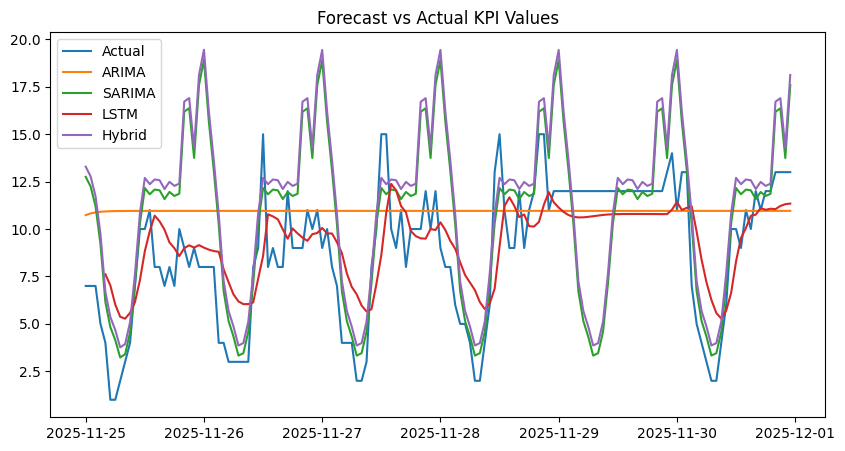

In [13]:
# -------------------------------------------------------
# Forecast Plot
# -------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.plot(test.index[-len(lstm_pred):], lstm_pred, label="LSTM")
plt.plot(test.index, hybrid_forecast, label="Hybrid")

plt.legend()

plt.title("Forecast vs Actual KPI Values")

plt.show()

In [11]:
# -------------------------------------------------------
# Model Comparison Table
# -------------------------------------------------------

results = pd.DataFrame({
    "Model":["ARIMA","SARIMA","LSTM","Hybrid"],
    "MAE":[arima_mae, sarima_mae, lstm_mae, hybrid_mae],
    "RMSE":[arima_rmse, sarima_rmse, lstm_rmse, hybrid_rmse]
})

print(results)

    Model       MAE      RMSE
0   ARIMA  3.195048  4.187001
1  SARIMA  2.993598  3.916923
2    LSTM  2.123356  2.583882
3  Hybrid  2.993598  3.916923
